# Comparing Exponential Poisson and Hawkes Intensities

This notebook combines the core ideas and code from `intensity_hawkes.py` and `compare_intensity.py`.

We will:

- Recall the **exponential Poisson intensity** used in Guéant (2017)
- Introduce a **Hawkes-based intensity** with Softplus nonlinearity
- Visualize and compare:
  - Intensity vs quote distance \(\delta\)
  - Fill probabilities
  - Excitation dynamics over time
  - Monte Carlo fill distributions (Poisson vs Hawkes)

The goal is to understand **how clustering of arrivals** (via Hawkes) changes the behaviour relative to the baseline Poisson model that underlies the original ODE policy.

# 1. Model Recap

---

## 1.1 Exponential Poisson Intensity (Guéant 2017)

In the original market-making model, the **arrival intensity** of trades at a quote distance $\delta$ from the mid-price is assumed exponential:

$$
\Lambda(\delta) = A \, e^{-k \delta}
$$

where:

- $A > 0$ is the baseline arrival rate when quoting at the mid ($\delta = 0$),
- $k > 0$ controls how fast intensity decays as quotes move away from the mid.

---

### Poisson Fill Model

Over a small time interval $\Delta t$, the number of fills follows a Poisson distribution:

$$
N \sim \text{Poisson}\big(\Lambda(\delta)\, \Delta t\big)
$$

The probability of **at least one fill** in $[t, t+\Delta t]$ is:

$$
\mathbb{P}(\text{at least one fill})
=
1 - e^{-\Lambda(\delta)\Delta t}
$$

---

### Interpretation

- Smaller $\delta$ → higher intensity → more fills  
- Larger $\delta$ → lower intensity → fewer fills  
- Arrivals are **memoryless**
- Variance equals mean
- No clustering of trades

This model is elegant but unrealistic for real order books.

---

## 1.2 Hawkes-Based Intensity (Lalor & Swishchuk 2025)

The paper models limit order book events using a **nonlinear multivariate Hawkes process**:

$$
\lambda_i(t)
=
\phi_i\left(
\bar{\lambda}_i
+
\int_0^t
\sum_{j=1}^m
\alpha_{ij}
\, e^{-\beta_{ij}(t-s)}
\, dN_j(s)
\right)
$$

where:

- $N_j(t)$ counts events of type $j$,
- $\alpha_{ij}$ controls excitation strength,
- $\beta_{ij}$ controls decay speed,
- $\phi_i(\cdot)$ is a nonlinear transfer function.

---

### Softplus Nonlinearity

In the implementation, the nonlinear transfer is the **Softplus function**:

$$
\phi(x) = \log(1 + e^x)
$$

This ensures intensity is always positive while allowing smooth nonlinear behavior.

---

## 1.3 Reduced Execution-Focused Model

For a single-asset market maker, we simplify the model to track only:

- Bid fills
- Ask fills

We keep the Guéant exponential baseline and add excitation:

$$
\lambda_{\text{bid}}(t)
=
\phi\bigl(
\Lambda(\delta_t^b)
+
y_{\text{bid}}(t)
\bigr)
$$

$$
\lambda_{\text{ask}}(t)
=
\phi\bigl(
\Lambda(\delta_t^a)
+
y_{\text{ask}}(t)
\bigr)
$$

---

## 1.4 Excitation Dynamics

The excitation states follow a discrete-time exponential kernel.

### Decay Step

Over time interval $\Delta t$:

$$
y(t + \Delta t)
=
y(t)\, e^{-\beta \Delta t}
$$

---

### Jump on Fill

If a **bid fill** occurs:

$$
y_{\text{bid}}
\leftarrow
y_{\text{bid}} + \alpha_{\text{self}}
$$

$$
y_{\text{ask}}
\leftarrow
y_{\text{ask}} + \alpha_{\text{cross}}
$$

This creates **clusters of fills**: one execution briefly increases the probability of further executions before the excitation decays back toward zero.

In [16]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.intensity import Lambda
from market_making.core.hawkes import (
    softplus,
    lambda_hawkes,
    lambda_hawkes_linear,
    fill_prob_from_intensity,
    HawkesState,
    DEFAULT_HAWKES_CFG,
)

In [17]:
# Inline parameters (simplified IG / HY proxies)
GAMMA = 0.1

IG = dict(sigma=0.3/100, A=140.0, k=1.5, Delta=0.01, Q=4)
HY = dict(sigma=1.5/100, A=40.0,  k=0.5, Delta=0.05, Q=4)

HAWKES_CFG = dict(beta=10.0, alpha_self=2.0, alpha_cross=0.5)

C_POISSON = "#2563EB"   # blue  — original
C_HAWKES  = "#DC2626"   # red   — Hawkes (no excitation)
C_EXCITED = "#16A34A"   # green — Hawkes (with excitation)
C_LINEAR  = "#9333EA"   # purple — linear Hawkes (legacy)

## 2. Softplus and Hawkes intensity

We start by reusing the core building blocks from `intensity_hawkes.py`:

- **Softplus** transfer function:
  $$\phi(x) = \log(1 + e^x)$$
  which ensures \(\lambda(t) \ge 0\) and behaves like \(x\) for large positive inputs and like \(e^x\) for large negative inputs.

- **Hawkes intensity** built on top of the baseline \(\Lambda(\delta)\):
  \[ \lambda(t) = \phi\bigl(\Lambda(\delta) + y(t)\bigr). \]

- **Linear comparison** (legacy model):
  $$\lambda_{\text{lin}}(t) = \max\{\Lambda(\delta) + y(t),\, 0\}$$

The following cells use the imported implementations directly rather than redefining them.

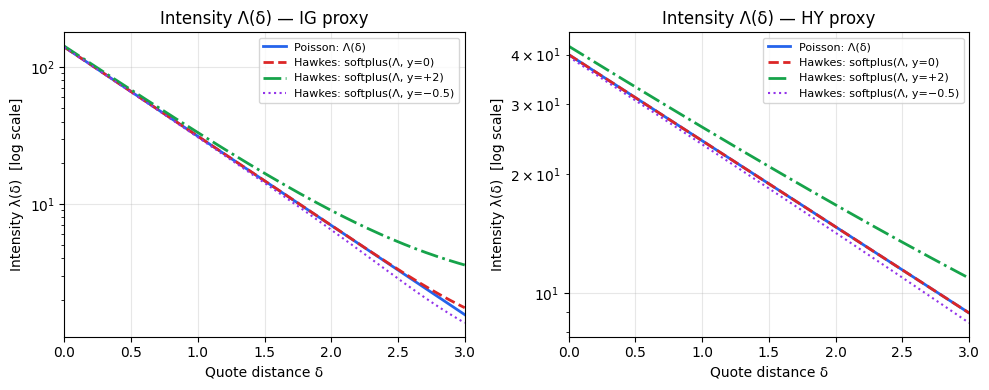

In [18]:
# 3. Intensity vs quote distance δ

def plot_intensity_vs_delta(ax, params, title):
    delta = np.linspace(0, 3.0, 300)
    A, k  = params["A"], params["k"]

    lam_poisson   = Lambda(delta, A, k)                     # A·exp(-kδ)
    lam_h0        = lambda_hawkes(lam_poisson, 0.0)         # softplus(Λ)
    lam_h_excited = lambda_hawkes(lam_poisson, 2.0)         # softplus(Λ + y)
    lam_h_inhib   = lambda_hawkes(lam_poisson, -0.5)        # softplus(Λ − y)

    ax.semilogy(delta, lam_poisson,   color=C_POISSON, lw=2,   label="Poisson: Λ(δ)")
    ax.semilogy(delta, lam_h0,        color=C_HAWKES,  lw=2,   ls="--",
                label="Hawkes: softplus(Λ, y=0)")
    ax.semilogy(delta, lam_h_excited, color=C_EXCITED, lw=2,   ls="-.",
                label="Hawkes: softplus(Λ, y=+2)")
    ax.semilogy(delta, lam_h_inhib,   color=C_LINEAR,  lw=1.5, ls=":",
                label="Hawkes: softplus(Λ, y=−0.5)")

    ax.set_xlabel("Quote distance δ")
    ax.set_ylabel("Intensity λ(δ)  [log scale]")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 3)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_intensity_vs_delta(axes[0], IG, "Intensity Λ(δ) — IG proxy")
plot_intensity_vs_delta(axes[1], HY, "Intensity Λ(δ) — HY proxy")
plt.tight_layout()

## 3. Fill Probabilities

For a given intensity $\lambda$ and time step $\Delta t$, the **exact** fill probability is

$$
\mathbb{P}(\text{fill in }[t, t+\Delta t])
=
1 - e^{-\lambda \Delta t}.
$$

In legacy Poisson simulations, one often uses the first-order approximation

$$
\lambda \Delta t.
$$

The difference becomes important when $\lambda$ is large (e.g. very tight quotes).

Below we compare:

- **Poisson (first-order approximation):**
  $$
  \lambda \Delta t
  $$

- **Poisson (exact):**
  $$
  1 - e^{-\lambda \Delta t}
  $$

- **Hawkes (exact):**
  $$
  1 - e^{-\lambda_{\text{Hawkes}}(\delta)\,\Delta t}
  $$

TypeError: only length-1 arrays can be converted to Python scalars

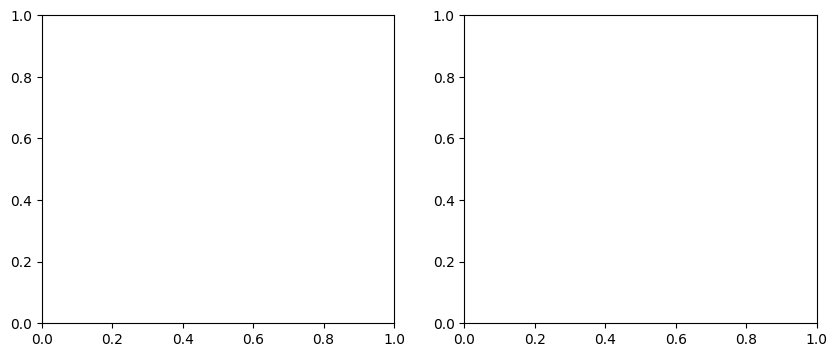

In [19]:
def plot_fill_prob(ax, params, title, dt=0.001):
    delta = np.linspace(0, 3.0, 300)
    A, k  = params["A"], params["k"]

    lam    = Lambda(delta, A, k)
    p_old  = np.minimum(lam * dt, 1.0)                # first-order approx
    p_new  = fill_prob_from_intensity(lam, dt)        # exact Poisson
    p_hawk = fill_prob_from_intensity(
        lambda_hawkes(lam, 2.0), dt                   # Hawkes + excitation
    )

    ax.plot(delta, p_old,  color=C_POISSON, lw=2,   label=f"Poisson: λ·dt  (dt={dt}s)")
    ax.plot(delta, p_new,  color=C_HAWKES,  lw=2,   ls="--",
            label="Poisson: 1−exp(−λ·dt)  (exact)")
    ax.plot(delta, p_hawk, color=C_EXCITED, lw=2,   ls="-.",
            label="Hawkes exact, y=+2")

    ax.set_xlabel("Quote distance δ")
    ax.set_ylabel("P(fill per step)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_fill_prob(axes[0], IG, "Fill probability vs δ — IG")
plot_fill_prob(axes[1], HY, "Fill probability vs δ — HY")
plt.tight_layout()

## 4. Excitation Dynamics and Fill Clustering

Next we visualize how the Hawkes excitation state drives the intensity over time.

We fix a flat baseline

$$
\mu = \Lambda(\delta)
$$

and inject a few **synthetic fills** at chosen times.

Each fill:

- Instantly increases the excitation state $y(t)$
- Hence boosts the intensity
  $$
  \lambda(t) = \phi\bigl(\mu + y(t)\bigr)
  $$
- Then the effect decays exponentially at rate $\beta$

The excitation dynamics follow:

### Exponential Decay

Between fills:

$$
y(t + \Delta t)
=
y(t)\, e^{-\beta \Delta t}
$$

### Jump on Fill

At a fill time $t_f$:

$$
y(t_f^+) = y(t_f^-) + \alpha
$$

This creates **bursts of elevated intensity** after each fill, followed by gradual decay back toward the baseline.

As a result, fills tend to **cluster in time**:

- A fill increases intensity
- Higher intensity increases the probability of another fill
- Which further increases excitation
- Until decay dominates

This behavior contrasts sharply with the Poisson model, where intensity is constant and arrivals are memoryless.

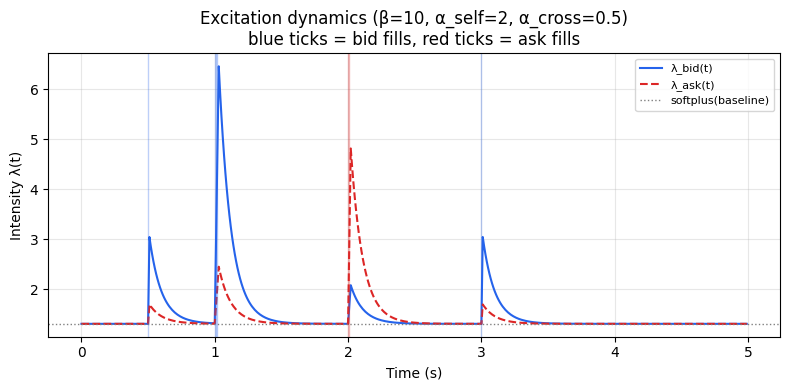

In [ ]:
def plot_excitation_dynamics(ax):
    dt   = 0.01
    T    = 5.0
    N    = int(T / dt)
    time = np.arange(N) * dt

    cfg   = HAWKES_CFG
    state = HawkesState(cfg)
    mu    = 1.0  # fixed baseline (flat quotes)

    y_bid_hist  = np.zeros(N)
    y_ask_hist  = np.zeros(N)
    lam_bid_hist= np.zeros(N)
    lam_ask_hist= np.zeros(N)

    # Synthetic fill times
    fill_bid_times = {0.5, 1.0, 1.01, 1.02, 3.0}
    fill_ask_times = {2.0, 2.01}

    for i in range(N):
        t = time[i]
        y_bid_hist[i]   = state.y_bid
        y_ask_hist[i]   = state.y_ask
        lam_bid_hist[i] = state.lambda_bid(mu)
        lam_ask_hist[i] = state.lambda_ask(mu)

        fb = any(abs(t - s) < dt/2 for s in fill_bid_times)
        fa = any(abs(t - s) < dt/2 for s in fill_ask_times)
        state.step(dt, fb, fa)

    ax.plot(time, lam_bid_hist, color=C_POISSON, lw=1.5, label="λ_bid(t)")
    ax.plot(time, lam_ask_hist, color=C_HAWKES,  lw=1.5, label="λ_ask(t)", ls="--")
    ax.axhline(softplus(mu), color="gray", lw=1, ls=":", label="softplus(baseline)")

    for s in sorted(fill_bid_times):
        ax.axvline(s, color=C_POISSON, alpha=0.3, lw=1)
    for s in sorted(fill_ask_times):
        ax.axvline(s, color=C_HAWKES,  alpha=0.3, lw=1)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Intensity λ(t)")
    ax.set_title("Excitation dynamics (β=10, α_self=2, α_cross=0.5)\n"
                 "blue ticks = bid fills, red ticks = ask fills")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_excitation_dynamics(ax)
plt.tight_layout()

## 5. Monte Carlo Fill Counts: Poisson vs Hawkes

Finally, we reproduce the Monte Carlo comparison from `compare_intensity.py` in a lighter form.

For each asset (IG/HY proxies), we:

- Simulate many short paths under **Poisson** fills with intensity  
  $$
  \Lambda(\delta)
  $$

- Simulate the same number of paths under **Hawkes** fills with time-varying intensity  
  $$
  \lambda_{\text{Hawkes}}(t)
  $$

- Compare the distribution of **total bid fills per path**.

---

### Poisson Benchmark

Under the Poisson model:

$$
N \sim \text{Poisson}\big(\Lambda(\delta) T\big)
$$

- Mean = Variance  
- No clustering  
- Independent arrivals  

---

### Hawkes Model

Under the Hawkes model:

$$
\lambda(t) = \phi\bigl(\Lambda(\delta) + y(t)\bigr)
$$

where the excitation state evolves as:

- **Decay**
  $$
  y(t + \Delta t) = y(t) e^{-\beta \Delta t}
  $$

- **Jump on fill**
  $$
  y(t_f^+) = y(t_f^-) + \alpha
  $$

Because fills increase future intensity, arrivals cluster in time.

---

### Key Result

Monte Carlo simulations show that Hawkes dynamics:

- Increase the **mean** number of fills per path  
- Increase the **variance (dispersion)** of fill counts  
- Generate **heavy right tails** (bursty paths)

This contrasts with the Poisson model, where dispersion equals the mean and no clustering occurs.

The difference becomes especially pronounced when:

- Quotes are tight (high baseline intensity)
- Excitation parameters $\alpha$ are large
- Decay rate $\beta$ is slow

TypeError: only length-1 arrays can be converted to Python scalars

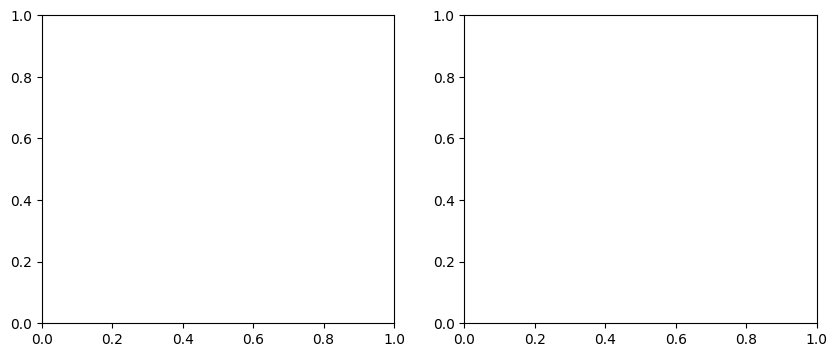

In [ ]:
def simulate_fills(params, cfg, T=60.0, dt=0.001, n_paths=200,
                   delta_bid=1.0, delta_ask=1.0):
    """Run n_paths simulations and collect bid/ask fill counts per path."""
    A, k   = params["A"], params["k"]
    N      = int(T / dt)
    beta   = cfg["beta"]
    a_self = cfg["alpha_self"]
    a_cros = cfg["alpha_cross"]
    decay  = np.exp(-beta * dt)

    mu_bid = Lambda(delta_bid, A, k)
    mu_ask = Lambda(delta_ask, A, k)

    rng = np.random.default_rng(0)

    # Poisson (independent)
    pb = fill_prob_from_intensity(mu_bid, dt)
    pa = fill_prob_from_intensity(mu_ask, dt)
    fills_poisson = np.column_stack([
        rng.binomial(N, pb, n_paths).astype(float),
        rng.binomial(N, pa, n_paths).astype(float),
    ])

    # Hawkes (with excitation)
    y_bid = np.zeros(n_paths)
    y_ask = np.zeros(n_paths)
    fb_count = np.zeros(n_paths)
    fa_count = np.zeros(n_paths)

    for _ in range(N):
        lb = softplus(mu_bid + y_bid)
        la = softplus(mu_ask + y_ask)
        fb = rng.random(n_paths) < fill_prob_from_intensity(lb, dt)
        fa = rng.random(n_paths) < fill_prob_from_intensity(la, dt)
        fb_count += fb
        fa_count += fa
        # decay then jump
        y_bid = y_bid * decay + fb * a_self  + fa * a_cros
        y_ask = y_ask * decay + fa * a_self  + fb * a_cros

    fills_hawkes = np.column_stack([fb_count, fa_count])
    return fills_poisson, fills_hawkes


def plot_fill_distribution(ax, params, cfg, title):
    fp, fh = simulate_fills(params, cfg)

    bid_p, ask_p = fp[:, 0], fp[:, 1]
    bid_h, ask_h = fh[:, 0], fh[:, 1]

    bins = np.linspace(
        min(bid_p.min(), bid_h.min()) * 0.9,
        max(bid_p.max(), bid_h.max()) * 1.1,
        25,
    )

    ax.hist(bid_p, bins=bins, color=C_POISSON, alpha=0.5,
            label=f"Poisson bid fills  μ={bid_p.mean():.0f}")
    ax.hist(bid_h, bins=bins, color=C_EXCITED, alpha=0.5,
            label=f"Hawkes bid fills   μ={bid_h.mean():.0f}")

    ax.axvline(bid_p.mean(), color=C_POISSON, lw=2, ls="--")
    ax.axvline(bid_h.mean(), color=C_EXCITED, lw=2, ls="--")

    ax.set_xlabel("Total bid fills per path")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_fill_distribution(axes[0], IG, HAWKES_CFG,
                       "Fill count distribution — IG proxy")
plot_fill_distribution(axes[1], HY, HAWKES_CFG,
                       "Fill count distribution — HY proxy")
plt.tight_layout()